In [2]:
import pandas as pd

df = pd.read_csv("books.csv")

df.head()
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1000 non-null   str    
 1   Price         1000 non-null   float64
 2   Rating        1000 non-null   str    
 3   Availability  1000 non-null   str    
dtypes: float64(1), str(3)
memory usage: 81.1 KB


,Price
count,1000.00000
mean,35.07035
std,14.44669
min,10.00000
25%,22.10750
50%,35.98000
75%,47.45750
max,59.99000


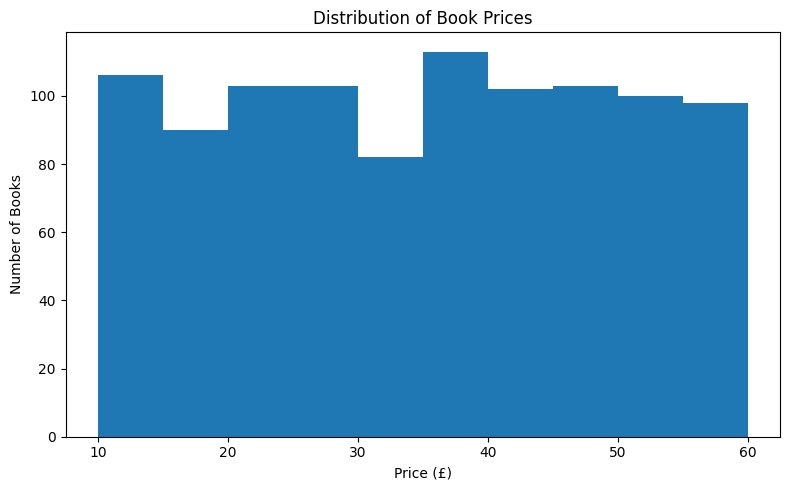

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=10)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.savefig("images/01_price_distribution.png")
plt.show()

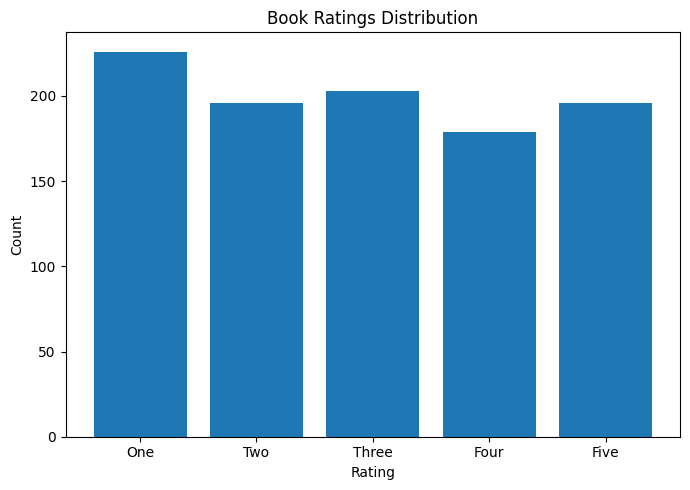

In [4]:
rating_order = ["One","Two","Three","Four","Five"]

rating_counts = (
    df["Rating"]
    .value_counts()
    .reindex(rating_order)
)

plt.figure(figsize=(7,5))

plt.bar(rating_counts.index, rating_counts.values)

plt.title("Book Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("images/02_rating_distribution.png")
plt.show()

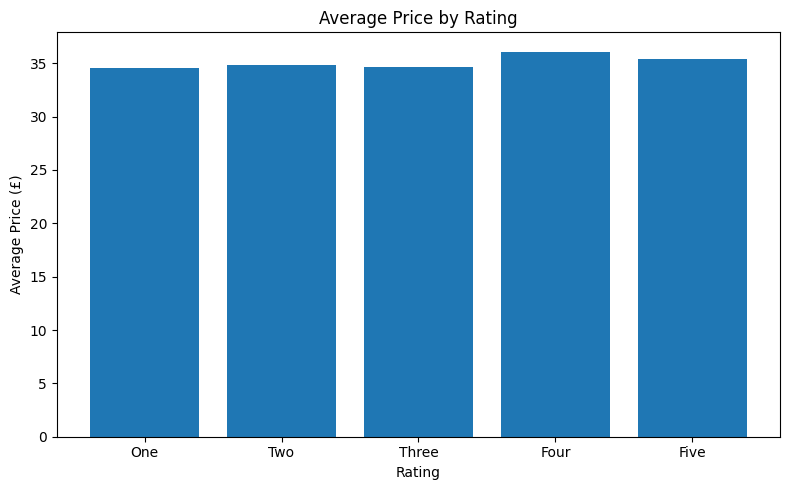

In [6]:
avg_price = df.groupby("Rating")["Price"].mean()

avg_price = avg_price.reindex(rating_order)

plt.figure(figsize=(8,5))

plt.bar(avg_price.index, avg_price.values)

plt.title("Average Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price (£)")

plt.tight_layout()

plt.savefig("images/04_average_price_rating.png")

plt.show()

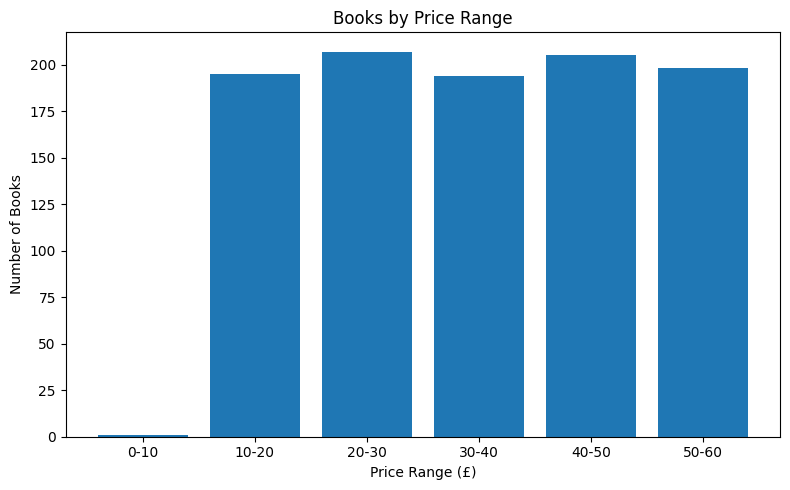

In [7]:
bins = [0,10,20,30,40,50,60]

labels = [
    "0-10",
    "10-20",
    "20-30",
    "30-40",
    "40-50",
    "50-60"
]

df["Price Range"] = pd.cut(
    df["Price"],
    bins=bins,
    labels=labels
)

price_range = df["Price Range"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(price_range.index.astype(str), price_range.values)

plt.title("Books by Price Range")
plt.xlabel("Price Range (£)")
plt.ylabel("Number of Books")

plt.tight_layout()

plt.savefig("images/05_price_range.png")

plt.show()

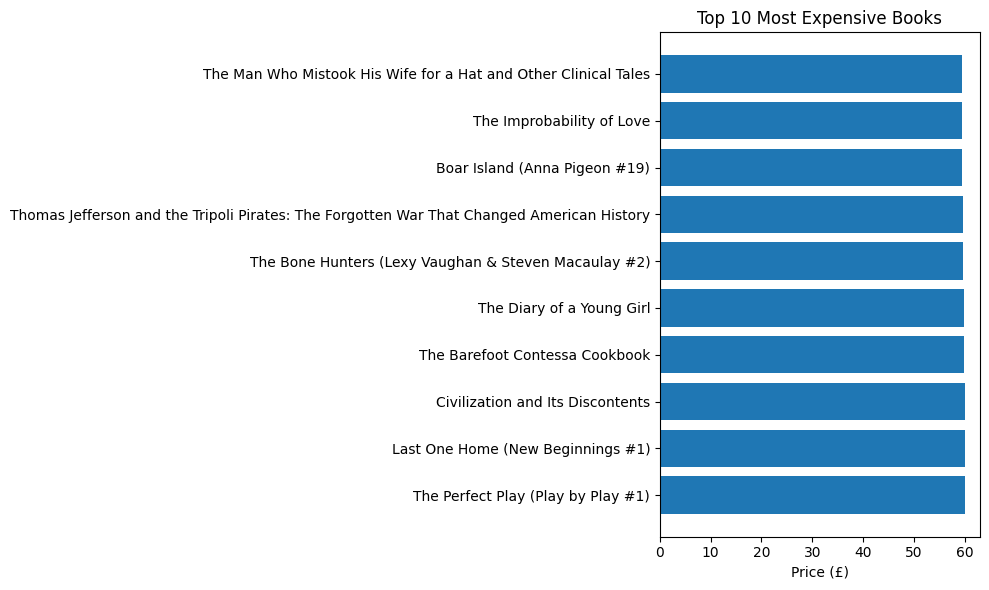

In [8]:
top_books = df.nlargest(10, "Price")

plt.figure(figsize=(10,6))

plt.barh(top_books["Title"], top_books["Price"])

plt.title("Top 10 Most Expensive Books")
plt.xlabel("Price (£)")

plt.tight_layout()

plt.savefig("images/06_top_expensive_books.png")

plt.show()

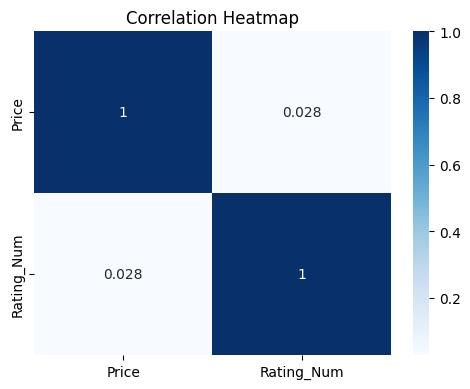

In [9]:
import seaborn as sns

rating_map = {
    "One":1,
    "Two":2,
    "Three":3,
    "Four":4,
    "Five":5
}

df["Rating_Num"] = df["Rating"].map(rating_map)

corr = df[["Price","Rating_Num"]].corr()

plt.figure(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("images/07_correlation_heatmap.png")

plt.show()

In [11]:
print("="*40)
print("TASK 3 : DATA VISUALIZATION")
print("="*40)

print("Dataset Shape :", df.shape)

print("Visualizations Created Successfully!")

print("""
Saved Images:

01_price_distribution.png
02_rating_distribution.png
03_average_price_rating.png
04_price_range.png
05_top_expensive_books.png
06_correlation_heatmap.png
""")

TASK 3 : DATA VISUALIZATION
Dataset Shape : (1000, 6)
Visualizations Created Successfully!

Saved Images:

01_price_distribution.png
02_rating_distribution.png
03_average_price_rating.png
04_price_range.png
05_top_expensive_books.png
06_correlation_heatmap.png

